In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


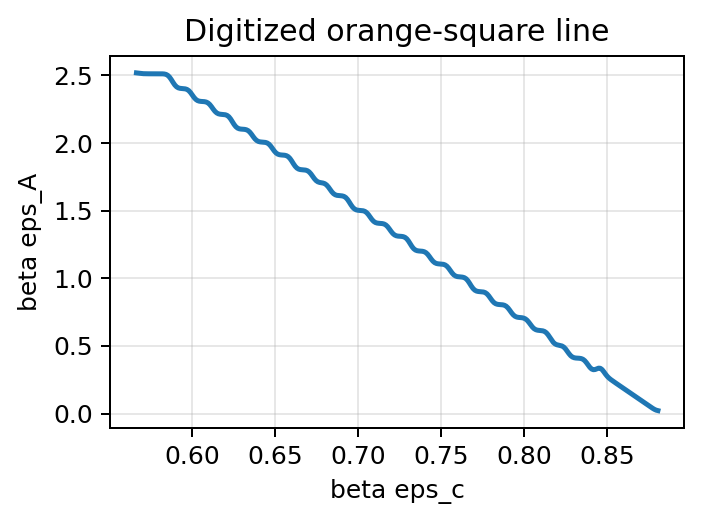

Saved orange_squares_digitized_curve.png
Approximate x-range: 0.566 to 0.881
Approximate y-range: 0.022 to 2.519


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import rgb_to_hsv
from scipy.ndimage import gaussian_filter1d

# stop drawing when they hit ~0 -> removes vertical end segment
#x3g, y3gs = trim_at_floor(x3g, y3gs, floor=0.0, eps=0.02)

img_path = Path("../figures/jacobs_curve.png")
arr = np.array(Image.open(img_path).convert("RGB"))

# Axis box estimated from the image
x_left, x_right = 158, 737
y_top, y_bottom = 59, 645

# Orange mask in HSV
hsv = rgb_to_hsv(arr / 255.0)
orange = (
    (hsv[..., 0] > 0.03) &
    (hsv[..., 0] < 0.08) &
    (hsv[..., 1] > 0.40) &
    (hsv[..., 2] > 0.50)
)

# ROI around the orange-square branch
x0, x1 = 486, 670
y0, y1 = 450, 645
roi = orange[y0:y1 + 1, x0:x1 + 1]

# Lower orange edge in ROI, then shift upward to approximate marker centers
edge_pts = []
for j in range(roi.shape[1]):
    ys = np.where(roi[:, j])[0]
    if len(ys):
        x = x0 + j
        y = y0 + ys.max()
        edge_pts.append((x, y))

edge_pts = np.array(edge_pts, dtype=float)

# Approximate centerline offset from lower edge
center = edge_pts.copy()
center[:, 1] -= 7.0

# Keep reliable segment before the heavy overlap at the bottom-right
main = center[center[:, 0] <= 648].copy()

# Extend smoothly to the visible endpoint using a linear fit over the tail
tail = main[main[:, 0] >= 620]
m, b = np.polyfit(tail[:, 0], tail[:, 1], 1)
x_ext = np.arange(main[-1, 0] + 1, 669)
if len(x_ext):
    y_ext = m * x_ext + b
    ext = np.column_stack([x_ext, y_ext])
    centerline_px = np.vstack([main, ext])
else:
    centerline_px = main

# Convert to plot coordinates
eps_c = (centerline_px[:, 0] - x_left) / (x_right - x_left)
eps_a = (y_bottom - centerline_px[:, 1]) / (y_bottom - y_top) * 8.0

# Light smoothing in data space
x_dense = np.linspace(eps_c.min(), eps_c.max(), 300)
y_interp = np.interp(x_dense, eps_c, eps_a)
y_smooth = gaussian_filter1d(y_interp, sigma=2.0)

curve_df = pd.DataFrame({
    "eps_c": x_dense,
    "eps_a": y_smooth,
})


curve_path = "../figures/orange_squares_digitized_curve.png"


# Standalone digitized curve
fig, ax = plt.subplots(figsize=(4.0, 3.0), dpi=180)
ax.plot(curve_df["eps_c"], curve_df["eps_a"], linewidth=2.0)
ax.set_xlabel("beta eps_c")
ax.set_ylabel("beta eps_A")
ax.set_title("Digitized orange-square line")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(curve_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved {curve_path}")
print(f"Approximate x-range: {curve_df['eps_c'].min():.3f} to {curve_df['eps_c'].max():.3f}")
print(f"Approximate y-range: {curve_df['eps_a'].min():.3f} to {curve_df['eps_a'].max():.3f}")


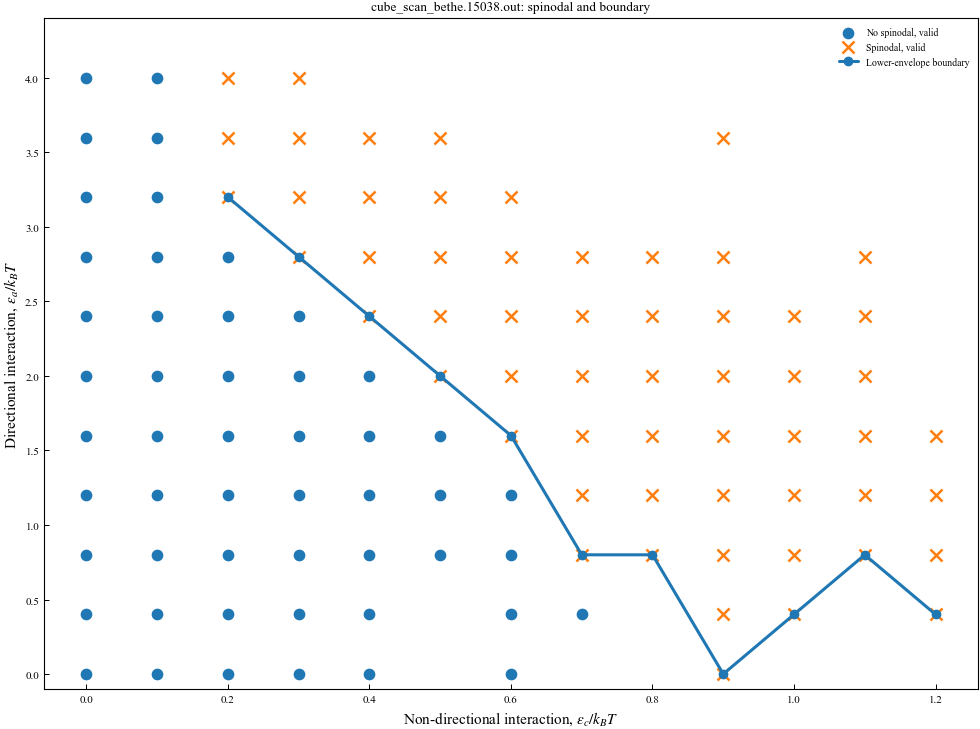

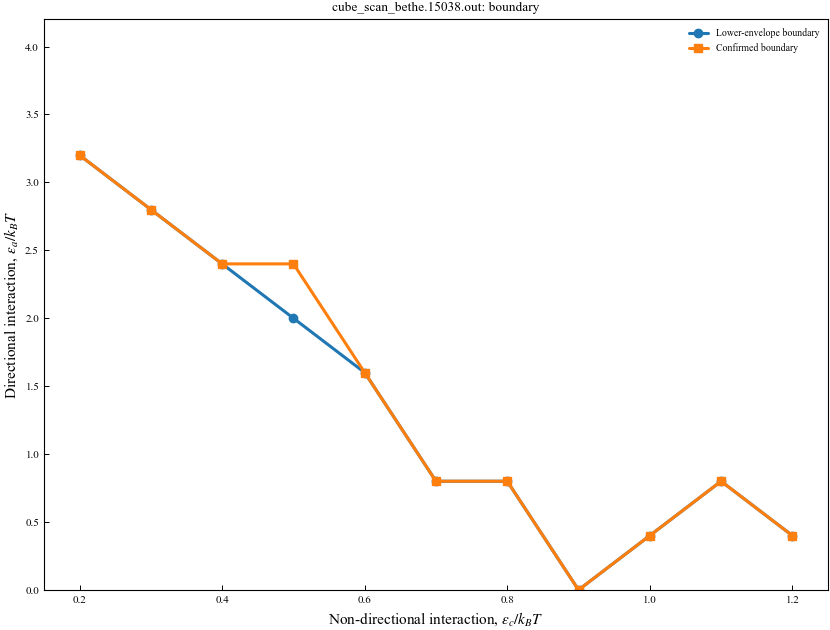

(<Figure size 850x650 with 1 Axes>,
 <Axes: title={'center': 'cube_scan_bethe.15038.out: boundary'}, xlabel='Non-directional interaction, $\\epsilon_c/k_BT$', ylabel='Directional interaction, $\\epsilon_a/k_BT$'>)

In [59]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# User settings
# =========================

LOG_PATH = Path("../results_logs/cube_scan_bethe.15038.out")   # change this
OUT_PREFIX = "run11442"

MAX_RES_CUTOFF = 1

# confirmed-boundary rule:
# requires confirm_k + 1 consecutive clearly unstable points
FPP_TOL_CONFIRM = 0.03
CONFIRM_K = 2

SAVE_FILES = True


# =========================
# Parser
# =========================

NUM = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?|nan|NaN|inf|-inf|INF|-INF"

POINT_RE = re.compile(
    rf"POINT .*?"
    rf"eps_a=({NUM})\s+eps_c=({NUM}).*?"
    rf"event=(\d+)\s+spin=(\d+)\s+bin=(\d+).*?"
    rf"min_fpp=({NUM})\s+phi_min_fpp=({NUM}).*?"
    rf"n_valid=(\d+)/(\d+).*?"
    rf"n_success=(\d+)\s+max_res=({NUM})",
    re.DOTALL,
)


def to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def parse_log(log_path):
    text = Path(log_path).read_text(errors="ignore")

    rows = []
    for m in POINT_RE.finditer(text):
        rows.append(
            {
                "eps_a": to_float(m.group(1)),
                "eps_c": to_float(m.group(2)),
                "event": int(m.group(3)),
                "spin": int(m.group(4)),
                "bin": int(m.group(5)),
                "min_fpp": to_float(m.group(6)),
                "phi_min_fpp": to_float(m.group(7)),
                "n_valid": int(m.group(8)),
                "n_phi": int(m.group(9)),
                "n_success": int(m.group(10)),
                "max_res": to_float(m.group(11)),
            }
        )

    df = pd.DataFrame(rows)

    if df.empty:
        raise RuntimeError(f"No POINT lines parsed from {log_path}")

    df = df.drop_duplicates().sort_values(["eps_c", "eps_a"]).reset_index(drop=True)
    return df


# =========================
# Classification
# =========================

def classify_points(df, max_res_cutoff=1e-2):
    df = df.copy()

    df["finite_min_fpp"] = np.isfinite(df["min_fpp"])
    df["finite_res"] = np.isfinite(df["max_res"])

    df["valid_solver"] = (
        df["finite_min_fpp"]
        & df["finite_res"]
        & (df["max_res"] <= max_res_cutoff)
        & (df["n_success"] > 0)
    )

    df["failed"] = ~df["finite_min_fpp"]
    df["suspect"] = df["finite_min_fpp"] & ~df["valid_solver"]

    df["valid_spinodal"] = (df["spin"] == 1) & df["valid_solver"]
    df["valid_nospinodal"] = (df["spin"] == 0) & df["valid_solver"]

    return df


def lower_envelope_boundary(df):
    spin_df = df[df["valid_spinodal"]].copy()

    if spin_df.empty:
        return pd.DataFrame(columns=["eps_c", "eps_a", "min_fpp"])

    # choose lowest eps_a spinodal for each eps_c
    idx = spin_df.groupby("eps_c")["eps_a"].idxmin()
    boundary = spin_df.loc[idx, ["eps_c", "eps_a", "min_fpp"]]
    boundary = boundary.sort_values("eps_c").reset_index(drop=True)

    return boundary


def confirmed_boundary(df, fpp_tol=0.03, confirm_k=1):
    """
    Conservative boundary.

    For each eps_c column, finds the first eps_a where there are
    confirm_k + 1 consecutive points satisfying:

        valid_solver = True
        spin = 1
        min_fpp < -fpp_tol

    This avoids isolated fake spinodal points.
    """
    rows = []

    for eps_c, col in df.groupby("eps_c"):
        col = col.sort_values("eps_a").reset_index(drop=True)

        unstable = (
            (col["valid_solver"])
            & (col["spin"] == 1)
            & np.isfinite(col["min_fpp"])
            & (col["min_fpp"] < -abs(fpp_tol))
        ).to_numpy()

        found = False

        for i in range(len(col)):
            j = i + confirm_k + 1

            if j <= len(col) and np.all(unstable[i:j]):
                prior = col.iloc[:i]
                prior_stable = prior[
                    (prior["valid_solver"])
                    & (prior["spin"] == 0)
                    & np.isfinite(prior["min_fpp"])
                ]

                eps_a_low = np.nan
                min_fpp_low = np.nan

                if not prior_stable.empty:
                    eps_a_low = float(prior_stable.iloc[-1]["eps_a"])
                    min_fpp_low = float(prior_stable.iloc[-1]["min_fpp"])

                rows.append(
                    {
                        "eps_c": float(eps_c),
                        "eps_a_boundary": float(col.iloc[i]["eps_a"]),
                        "min_fpp_boundary": float(col.iloc[i]["min_fpp"]),
                        "eps_a_low_last_stable": eps_a_low,
                        "min_fpp_low_last_stable": min_fpp_low,
                        "confirmed_points": confirm_k + 1,
                    }
                )
                found = True
                break

        if not found:
            rows.append(
                {
                    "eps_c": float(eps_c),
                    "eps_a_boundary": np.nan,
                    "min_fpp_boundary": np.nan,
                    "eps_a_low_last_stable": np.nan,
                    "min_fpp_low_last_stable": np.nan,
                    "confirmed_points": 0,
                }
            )

    return pd.DataFrame(rows).sort_values("eps_c").reset_index(drop=True)


# =========================
# Plotting
# =========================

def plot_points(df, lower_boundary, title, save_prefix=None):
    valid_no = df[df["valid_nospinodal"]]
    valid_spin = df[df["valid_spinodal"]]
    suspect = df[df["suspect"]]
    failed = df[df["failed"]]

    fig, ax = plt.subplots(figsize=(10, 7.5))

    if len(valid_no):
        ax.scatter(
            valid_no["eps_c"],
            valid_no["eps_a"],
            marker="o",
            s=55,
            label="No spinodal, valid",
        )

    if len(valid_spin):
        ax.scatter(
            valid_spin["eps_c"],
            valid_spin["eps_a"],
            marker="x",
            s=75,
            label="Spinodal, valid",
        )

    if len(suspect):
        ax.scatter(
            suspect["eps_c"],
            suspect["eps_a"],
            marker="s",
            s=55,
            label="Finite but suspect residual",
        )

    if len(failed):
        ax.scatter(
            failed["eps_c"],
            failed["eps_a"],
            marker="^",
            s=70,
            label="Failed / min_fpp=nan",
        )

    if len(lower_boundary):
        ax.plot(
            lower_boundary["eps_c"],
            lower_boundary["eps_a"],
            marker="o",
            linewidth=2.2,
            label="Lower-envelope boundary",
        )

    ax.set_xlabel(r"Non-directional interaction, $\epsilon_c/k_BT$")
    ax.set_ylabel(r"Directional interaction, $\epsilon_a/k_BT$")
    ax.set_title(title)
    #ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.1, max(float(df["eps_a"].max()) + 0.4, 4.2))
    ax.legend()
    fig.tight_layout()

    if save_prefix is not None:
        fig.savefig(f"{save_prefix}.png", dpi=220, bbox_inches="tight")
        fig.savefig(f"{save_prefix}.pdf", bbox_inches="tight")

    plt.show()
    return fig, ax


def plot_boundary(lower_boundary, confirmed, title, save_prefix=None):
    fig, ax = plt.subplots(figsize=(8.5, 6.5))

    if len(lower_boundary):
        ax.plot(
            lower_boundary["eps_c"],
            lower_boundary["eps_a"],
            marker="o",
            linewidth=2.2,
            label="Lower-envelope boundary",
        )

    confirmed_valid = confirmed[np.isfinite(confirmed["eps_a_boundary"])]

    if len(confirmed_valid):
        ax.plot(
            confirmed_valid["eps_c"],
            confirmed_valid["eps_a_boundary"],
            marker="s",
            linewidth=2.2,
            label="Confirmed boundary",
        )

    ax.set_xlabel(r"Non-directional interaction, $\epsilon_c/k_BT$")
    ax.set_ylabel(r"Directional interaction, $\epsilon_a/k_BT$")
    ax.set_title(title)
    #ax.set_xlim(0.0, 1.0)

    ymax = 4.2
    if len(lower_boundary):
        ymax = max(ymax, float(np.nanmax(lower_boundary["eps_a"])) + 0.5)
    if len(confirmed_valid):
        ymax = max(ymax, float(np.nanmax(confirmed_valid["eps_a_boundary"])) + 0.5)

    ax.set_ylim(0.0, ymax)
    ax.legend()
    fig.tight_layout()

    if save_prefix is not None:
        fig.savefig(f"{save_prefix}.png", dpi=220, bbox_inches="tight")
        fig.savefig(f"{save_prefix}.pdf", bbox_inches="tight")

    plt.show()
    return fig, ax


# =========================
# Run
# =========================

df = parse_log(LOG_PATH)
df = classify_points(df, max_res_cutoff=MAX_RES_CUTOFF)

lower_boundary = lower_envelope_boundary(df)
confirmed = confirmed_boundary(
    df,
    fpp_tol=FPP_TOL_CONFIRM,
    confirm_k=0,
)

if SAVE_FILES:
    df.to_csv(f"{OUT_PREFIX}_all_points.csv", index=False)
    lower_boundary.to_csv(f"{OUT_PREFIX}_boundary_lower_envelope.csv", index=False)
    confirmed.to_csv(f"{OUT_PREFIX}_boundary_confirmed.csv", index=False)

plot_points(
    df,
    lower_boundary,
    title=f"{LOG_PATH.name}: spinodal and boundary",
    save_prefix=f"{OUT_PREFIX}_points" if SAVE_FILES else None,
)

plot_boundary(
    lower_boundary,
    confirmed,
    title=f"{LOG_PATH.name}: boundary",
    save_prefix=f"{OUT_PREFIX}_boundary" if SAVE_FILES else None,
)


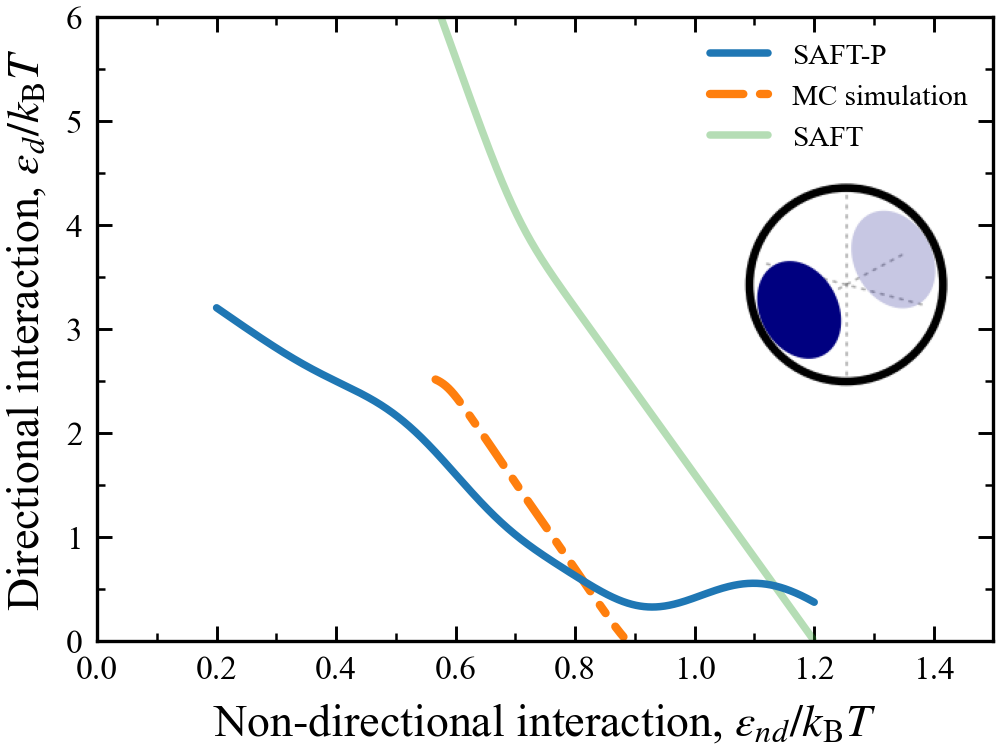

Log file: cube_scan_bethe.15038.out
Total POINT rows parsed: 109
Spinodal points parsed: 58
Boundary points used: 11
Saved cube_scan_stick3d.png
Saved cube_scan_11312_spinodal_overlay.pdf


In [62]:
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

# -------------------- load SAFT-P spinodal scan from LOG --------------------
log_path = Path("../results_logs/cube_scan_bethe.15038.out")

rows = []
with open(log_path, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()

        if "POINT " not in s or "eps_a=" not in s or "eps_c=" not in s:
            continue

        def get_float(key, default=np.nan):
            m = re.search(rf"{key}=([^\s]+)", s)
            if m is None:
                return default
            try:
                return float(m.group(1))
            except ValueError:
                return default

        def get_int(key, default=0):
            m = re.search(rf"{key}=([^\s]+)", s)
            if m is None:
                return default
            try:
                return int(m.group(1))
            except ValueError:
                return default

        rows.append({
            "eps_a": get_float("eps_a"),
            "eps_c": get_float("eps_c"),
            "event": get_int("event"),
            "spin": get_int("spin"),
            "bin": get_int("bin"),
            "min_fpp": get_float("min_fpp"),
            "phi_min_fpp": get_float("phi_min_fpp"),
            "max_res": get_float("max_res"),
            "mean_res": get_float("mean_res"),
            "barrier": get_float("barrier"),
        })

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError(f"No POINT rows found in {log_path}")

# Keep only spinodal points
df = (
    df_all[df_all["spin"] == 1][["eps_a", "eps_c"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .drop_duplicates()
)

if df.empty:
    raise RuntimeError(f"No spinodal points found in {log_path}")

# Lower-envelope spinodal boundary:
# for each eps_c, smallest eps_a with spinodal
curve = (
    df.groupby("eps_c", as_index=False)["eps_a"]
      .min()
      .sort_values("eps_c")
      .reset_index(drop=True)
)

# -------------------- smoothing helpers --------------------
def _fit_slope(x, y, k=10, side="left"):
    k = min(int(k), len(x))
    if k < 2:
        return 0.0

    if side == "left":
        xx, yy = x[:k], y[:k]
    else:
        xx, yy = x[-k:], y[-k:]

    A = np.vstack([xx, np.ones_like(xx)]).T
    m, _ = np.linalg.lstsq(A, yy, rcond=None)[0]
    return float(m)

def gaussian_smooth_xy_no_edge_curvature(
    x,
    y,
    *,
    sigma=50.0,
    n=900,
    xlim=None,
    pad_mult=4,
    kfit=10,
):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    # Remove duplicate x values
    tmp = pd.DataFrame({"x": x, "y": y})
    tmp = tmp.groupby("x", as_index=False)["y"].mean()
    x = tmp["x"].to_numpy(float)
    y = tmp["y"].to_numpy(float)

    if len(x) < 2:
        return x, y

    if xlim is None:
        x0, x1 = float(x.min()), float(x.max())
    else:
        x0, x1 = map(float, xlim)
        keep = (x >= x0) & (x <= x1)
        x, y = x[keep], y[keep]

    if len(x) < 2:
        return x, y

    xg = np.linspace(x0, x1, int(n))
    yg = np.interp(xg, x, y)

    pad = int(max(3, pad_mult * sigma))
    dx = xg[1] - xg[0]

    mL = _fit_slope(xg, yg, k=kfit, side="left")
    mR = _fit_slope(xg, yg, k=kfit, side="right")

    left_x = xg[0] - dx * np.arange(pad, 0, -1)
    right_x = xg[-1] + dx * np.arange(1, pad + 1)

    left_y = yg[0] + mL * (left_x - xg[0])
    right_y = yg[-1] + mR * (right_x - xg[-1])

    yg_pad = np.concatenate([left_y, yg, right_y])
    ygs_pad = gaussian_filter1d(yg_pad, sigma=float(sigma), mode="nearest")
    ygs = ygs_pad[pad:-pad]

    return xg, ygs

def trim_at_floor(x, y, floor=0.0, eps=2e-2):
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    idx = np.where(y <= (floor + eps))[0]
    if idx.size == 0:
        return x, y

    k = int(idx[0])
    return x[:k + 1], y[:k + 1]

# -------------------- smooth SAFT-P from log --------------------
confirmed_valid = confirmed[np.isfinite(confirmed["eps_a_boundary"])]

x = confirmed_valid["eps_c"].to_numpy(float)
y = confirmed_valid["eps_a_boundary"].to_numpy(float)

xg, ygs = gaussian_smooth_xy_no_edge_curvature(
    x,
    y,
    sigma=70.0,
    n=900,
    #xlim=(0.0, 1.0),
)
#xg, ygs = trim_at_floor(xg, ygs, floor=0.0, eps=0.02)

# -------------------- smooth MC and SAFT references --------------------
# Assumes these already exist:
# curve_df columns: eps_c, eps_a
# eps_c_spinodal2_m, eps_a_spinodal2_m arrays/lists

xmc, ymc = gaussian_smooth_xy_no_edge_curvature(
    curve_df["eps_c"],
    curve_df["eps_a"],
    sigma=50.0,
    n=900,
    #xlim=(0.0, 1.0),
)
xmc, ymc = trim_at_floor(xmc, ymc, floor=0.0, eps=0.02)




# ============================================================
# PLOT
# ============================================================
def add_particle_png_inset(
    ax,
    image_path,
    bounds=(0.685, 0.365, 0.300, 0.410),
):
    """
    Add a patchy-particle PNG inside the plot.

    bounds = [left, bottom, width, height] in axes coordinates.
    This keeps the particle fixed relative to the plotting box, independent
    of the data limits.
    """
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Particle image not found: {image_path}. "
            "Put patchy_3d_corner3.png next to this script or change CORNER3_IMAGE_PATH."
        )

    img = Image.open(image_path).convert("RGBA")

    iax = ax.inset_axes(bounds, transform=ax.transAxes)
    iax.imshow(img)
    iax.set_axis_off()
    iax.set_facecolor((1, 1, 1, 0))

    # Keep the inset above the curves but below nothing else.
    iax.set_zorder(20)

    return iax


# ============================================================
# PLOT OVERLAY
# ============================================================

CORNER3_IMAGE_PATH='../figures/patchy_3d_stick.png'

with open("../data/spinodal_du_saft.json", "r") as f:
    data = json.load(f)
spinodal2_m=np.array(data)

eps_as=np.linspace(0,8,21)
eps_cs=np.linspace(0,1.5,31)
eps_c_spinodal2_m=[]
eps_a_spinodal2_m=[]
for j in range(len(eps_cs)):
    if len(np.where(spinodal2_m[:,j])[0])>0 and eps_cs[j]<1.22:
        eps_a_spinodal2_m.append(eps_as[np.min(np.where(spinodal2_m[:,j]==1)[0])])
        eps_c_spinodal2_m.append(eps_cs[j])
xsaft, ysaft = gaussian_smooth_xy_no_edge_curvature(
    eps_c_spinodal2_m,
    eps_a_spinodal2_m,
    sigma=50.0,
    n=900,
    #xlim=(0.0, 1.0),
)
xsaft, ysaft = trim_at_floor(xsaft, ysaft, floor=0.0, eps=0.02)



# -------------------- PRL/APS-like style --------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 11,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------- plot --------------------
png_path = "../figures/cube_scan_stick3d.png"
pdf_path = "../figures/cube_scan_11312_spinodal_overlay.pdf"

fig = plt.figure(figsize=(3.375, 2.55), dpi=300, constrained_layout=True)
ax = fig.add_subplot(111)
SHOW_CORNER3_INSET=True
ax.plot(xg, ygs, zorder=3, label="SAFT-P")
ax.plot(xmc, ymc, linewidth=2.0,linestyle=(0, (4, 2, 1.2, 2)), label="MC simulation")
ax.plot(xsaft, ysaft, alpha=0.35,label="SAFT")
if SHOW_CORNER3_INSET:
    add_particle_png_inset(
        ax,
        CORNER3_IMAGE_PATH,
    )
# Optional raw SAFT-P points from log
# ax.plot(df["eps_c"], df["eps_a"], "o", ms=2, alpha=0.35)

ax.set_xlabel(r"Non-directional interaction, $\epsilon_{nd}/k_{\mathrm{B}}T$")
ax.set_ylabel(r"Directional interaction, $\epsilon_d/k_{\mathrm{B}}T$")

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which="both", top=True, right=True)

ax.set_xlim(0.0, 1.5)
ax.set_ylim(0.0, 7)


ymax = np.nanmax([
    np.nanmax(ygs) if len(ygs) else 0,
    np.nanmax(ymc) if len(ymc) else 0,
    np.nanmax(ysaft) if len(ysaft) else 0,
])
ax.set_ylim(0.0, 6)

ax.legend()

fig.savefig(png_path, dpi=600)
fig.savefig(pdf_path)
plt.show()
plt.close(fig)

print(f"Log file: {log_path}")
print(f"Total POINT rows parsed: {len(df_all)}")
print(f"Spinodal points parsed: {len(df)}")
print(f"Boundary points used: {len(curve)}")
print(f"Saved {png_path}")
print(f"Saved {pdf_path}")

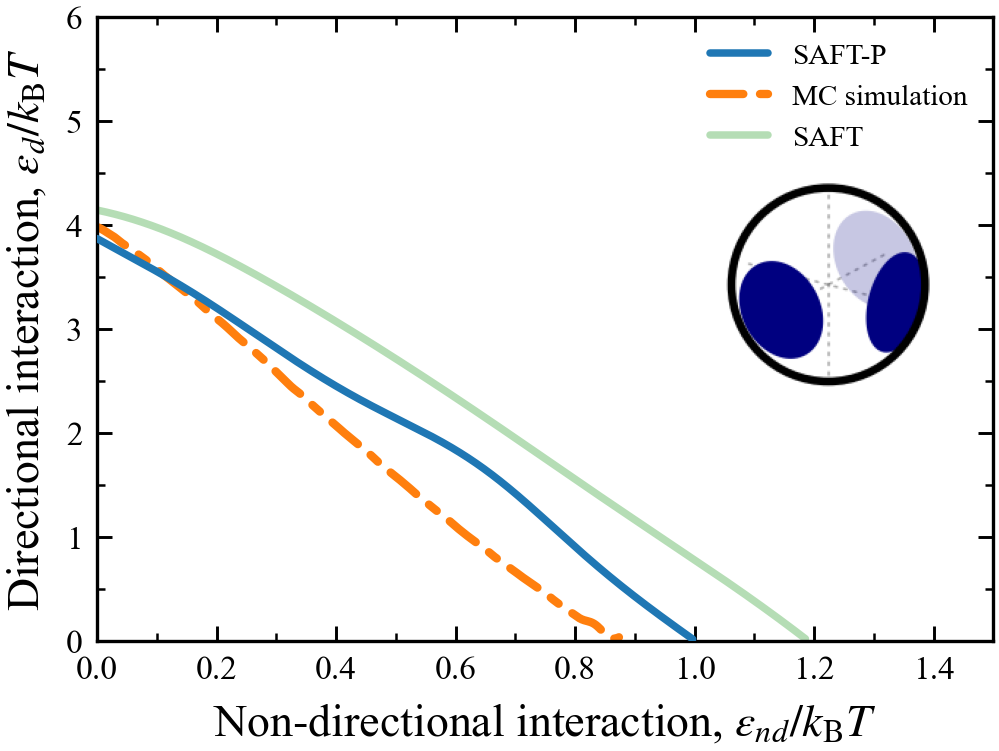

Figure file: jacobs_full_curve.png
Log file: cube_scan_bethe.11490.out
Total POINT rows parsed: 392
Valid SAFT-P spinodal points parsed: 83
SAFT-P boundary points used: 20
MC digitized points: 503
SAFT digitized points: 478
Saved cube_scan_planar3patch.png
Saved planar3patch_11469_overlay.pdf
Saved planar3patch_11469_overlay_mc_digitized.csv
Saved planar3patch_11469_overlay_saft_digitized.csv
Saved planar3patch_11469_overlay_saftp_boundary.csv
Saved planar3patch_11469_overlay_all_saftp_points.csv


In [6]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.ndimage import gaussian_filter1d
from PIL import Image


# ============================================================
# USER SETTINGS
# ============================================================

# Uploaded planar 3-patch figure.
# Change this if your local filename is different.
FIGURE_PATH = Path("../figures/jacobs_full_curve.png")

# SAFT-P scan log.
LOG_PATH = Path("../results_logs/cube_scan_bethe.11490.out")

OUT_PREFIX = "planar3patch_11469_overlay"

# Figure panel crop coordinates for the uploaded image:
# image size was 1406 x 910.
# Format: img[y0:y1, x0:x1]
LEFT_PANEL_CROP  = (70, 655, 77, 654)      # simulation panel
RIGHT_PANEL_CROP = (70, 655, 766, 1343)    # SAFT panel

# Axis ranges in the original figure
LEFT_XMAX = 1.0
RIGHT_XMAX = 0.8
YMAX = 8.0

# Smoothing
SMOOTH_SIGMA = 100.0
SMOOTH_N = 900

# Parser quality cutoff
MAX_RES_CUTOFF = 1e-1

# Save files
SAVE_FILES = True


# ============================================================
# SAFT-P LOG PARSER
# ============================================================

NUM = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?|nan|NaN|inf|-inf|INF|-INF"

POINT_RE = re.compile(
    rf"POINT .*?"
    rf"eps_a=({NUM})\s+eps_c=({NUM}).*?"
    rf"event=(\d+)\s+spin=(\d+)\s+bin=(\d+).*?"
    rf"min_fpp=({NUM})\s+phi_min_fpp=({NUM}).*?"
    rf"n_valid=(\d+)/(\d+).*?"
    rf"n_success=(\d+)\s+max_res=({NUM})",
    re.DOTALL,
)

def to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def parse_saftp_log(log_path, max_res_cutoff=1e-2):
    text = Path(log_path).read_text(errors="ignore")

    rows = []
    for m in POINT_RE.finditer(text):
        rows.append(
            {
                "eps_a": to_float(m.group(1)),
                "eps_c": to_float(m.group(2)),
                "event": int(m.group(3)),
                "spin": int(m.group(4)),
                "bin": int(m.group(5)),
                "min_fpp": to_float(m.group(6)),
                "phi_min_fpp": to_float(m.group(7)),
                "n_valid": int(m.group(8)),
                "n_phi": int(m.group(9)),
                "n_success": int(m.group(10)),
                "max_res": to_float(m.group(11)),
            }
        )

    df = pd.DataFrame(rows)

    if df.empty:
        raise RuntimeError(f"No POINT rows parsed from {log_path}")

    df = df.drop_duplicates().sort_values(["eps_c", "eps_a"]).reset_index(drop=True)

    df["valid_solver"] = (
        np.isfinite(df["min_fpp"])
        & np.isfinite(df["max_res"])
        & (df["max_res"] <= max_res_cutoff)
        & (df["n_success"] > 0)
    )

    df["valid_spinodal"] = (df["spin"] == 1) & df["valid_solver"]

    spin_df = df[df["valid_spinodal"]].copy()

    if spin_df.empty:
        raise RuntimeError(f"No valid spinodal points found in {log_path}")

    # Lower envelope: for each eps_c, smallest eps_a with spinodal
    idx = spin_df.groupby("eps_c")["eps_a"].idxmin()
    boundary = (
        spin_df.loc[idx, ["eps_c", "eps_a", "min_fpp"]]
        .sort_values("eps_c")
        .reset_index(drop=True)
    )

    return df, spin_df, boundary


# ============================================================
# DIGITIZATION HELPERS
# ============================================================

def rgb_to_hsv_array(rgb):
    rgb = rgb.astype(np.float32) / 255.0
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]

    mx = np.max(rgb, axis=-1)
    mn = np.min(rgb, axis=-1)
    diff = mx - mn

    h = np.zeros_like(mx)
    nz = diff != 0

    idx = (mx == r) & nz
    h[idx] = ((g[idx] - b[idx]) / diff[idx]) % 6

    idx = (mx == g) & nz
    h[idx] = ((b[idx] - r[idx]) / diff[idx]) + 2

    idx = (mx == b) & nz
    h[idx] = ((r[idx] - g[idx]) / diff[idx]) + 4

    h = h / 6.0

    s = np.where(mx == 0, 0, diff / mx)
    v = mx

    return h, s, v


def extract_green_curve_from_panel(
    panel_rgb,
    *,
    x_max,
    y_max,
    take="median",
    h_range=(0.23, 0.42),
    s_min=0.20,
    v_max=0.95,
    rolling_window=7,
):
    """
    Extracts green curves from a cropped panel.

    take:
        "bottom" -> use bottom-most green pixel in each column.
                    Good for MC green-square curve when there are two green MC curves.
        "top"    -> use top-most green pixel.
        "median" -> use median green pixel.
                    Good for the single green SAFT curve.
    """
    h, s, v = rgb_to_hsv_array(panel_rgb)

    mask = (
        (h > h_range[0])
        & (h < h_range[1])
        & (s > s_min)
        & (v < v_max)
    )

    xs = []
    ys = []

    for x in range(mask.shape[1]):
        yhits = np.where(mask[:, x])[0]
        if len(yhits) == 0:
            continue

        if take == "bottom":
            y = yhits.max()
        elif take == "top":
            y = yhits.min()
        elif take == "median":
            y = int(np.median(yhits))
        else:
            raise ValueError("take must be 'bottom', 'top', or 'median'")

        xs.append(x)
        ys.append(y)

    curve = pd.DataFrame({"px": xs, "py": ys})

    if curve.empty:
        raise RuntimeError("No green curve pixels extracted. Check crop or HSV thresholds.")

    curve["eps_c"] = x_max * curve["px"] / (mask.shape[1] - 1)
    curve["eps_a"] = y_max * (1.0 - curve["py"] / (mask.shape[0] - 1))

    # Average duplicate x-bins
    curve["xbin"] = curve["eps_c"].round(4)
    curve = (
        curve.groupby("xbin", as_index=False)[["eps_c", "eps_a"]]
        .mean()
        .sort_values("eps_c")
        .reset_index(drop=True)
    )

    # Remove pixel-scale jaggedness before final Gaussian smoothing
    if rolling_window is not None and rolling_window > 1:
        curve["eps_a"] = (
            curve["eps_a"]
            .rolling(window=int(rolling_window), center=True, min_periods=1)
            .median()
        )

    return curve[["eps_c", "eps_a"]]


# ============================================================
# SMOOTHING HELPERS
# ============================================================

def _fit_slope(x, y, k=10, side="left"):
    k = min(int(k), len(x))

    if k < 2:
        return 0.0

    if side == "left":
        xx, yy = x[:k], y[:k]
    else:
        xx, yy = x[-k:], y[-k:]

    A = np.vstack([xx, np.ones_like(xx)]).T
    m, _ = np.linalg.lstsq(A, yy, rcond=None)[0]
    return float(m)


def gaussian_smooth_xy_no_edge_curvature(
    x,
    y,
    *,
    sigma=50.0,
    n=900,
    xlim=None,
    pad_mult=4,
    kfit=10,
):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    tmp = pd.DataFrame({"x": x, "y": y})
    tmp = tmp.groupby("x", as_index=False)["y"].mean()
    x = tmp["x"].to_numpy(float)
    y = tmp["y"].to_numpy(float)

    if len(x) < 2:
        return x, y

    if xlim is None:
        x0, x1 = float(x.min()), float(x.max())
    else:
        x0, x1 = map(float, xlim)
        keep = (x >= x0) & (x <= x1)
        x, y = x[keep], y[keep]

    if len(x) < 2:
        return x, y

    xg = np.linspace(x0, x1, int(n))
    yg = np.interp(xg, x, y)

    pad = int(max(8, pad_mult * sigma))
    dx = xg[1] - xg[0]

    mL = _fit_slope(xg, yg, k=kfit, side="left")
    mR = _fit_slope(xg, yg, k=kfit, side="right")

    left_x = xg[0] - dx * np.arange(pad, 0, -1)
    right_x = xg[-1] + dx * np.arange(1, pad + 1)

    left_y = yg[0] + mL * (left_x - xg[0])
    right_y = yg[-1] + mR * (right_x - xg[-1])

    yg_pad = np.concatenate([left_y, yg, right_y])
    ygs_pad = gaussian_filter1d(yg_pad, sigma=float(sigma), mode="nearest")
    ygs = ygs_pad[pad:-pad]

    return xg, ygs


def trim_at_floor(x, y, floor=0.0, eps=2e-2):
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    idx = np.where(y <= (floor + eps))[0]

    if idx.size == 0:
        return x, y

    k = int(idx[0])
    return x[: k + 1], y[: k + 1]


# ============================================================
# LOAD + DIGITIZE FIGURE
# ============================================================

img = np.array(Image.open(FIGURE_PATH).convert("RGB"))

y0, y1, x0, x1 = LEFT_PANEL_CROP
left_panel = img[y0:y1, x0:x1]

y0, y1, x0, x1 = RIGHT_PANEL_CROP
right_panel = img[y0:y1, x0:x1]

# Green-square MC curve in simulation panel.
# Since the simulation panel has two green curves, "bottom" selects the lower green-square curve.
mc_digitized = extract_green_curve_from_panel(
    left_panel,
    x_max=LEFT_XMAX,
    y_max=YMAX,
    take="bottom",
)

# Green 3-patch SAFT curve in SAFT panel.
saft_digitized = extract_green_curve_from_panel(
    right_panel,
    x_max=RIGHT_XMAX,
    y_max=YMAX,
    take="median",
)


# ============================================================
# LOAD SAFT-P FROM LOG
# ============================================================

df_all, df_spin, saftp_boundary = parse_saftp_log(
    LOG_PATH,
    max_res_cutoff=MAX_RES_CUTOFF,
)


# ============================================================
# SMOOTH CURVES
# ============================================================

x_saftp, y_saftp = gaussian_smooth_xy_no_edge_curvature(
    saftp_boundary["eps_c"],
    saftp_boundary["eps_a"],
    sigma=SMOOTH_SIGMA,
    n=SMOOTH_N,
)
x_saftp, y_saftp = trim_at_floor(x_saftp, y_saftp, floor=0.0, eps=0.02)

x_mc, y_mc = gaussian_smooth_xy_no_edge_curvature(
    mc_digitized["eps_c"],
    mc_digitized["eps_a"],
    sigma=10,
    n=SMOOTH_N,
)
#x_mc, y_mc = trim_at_floor(x_mc, y_mc, floor=0.0, eps=0.02)




# ============================================================
# PRL/APS-LIKE STYLE
# ============================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 11,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# PLOT
# ============================================================
def add_particle_png_inset(
    ax,
    image_path,
    bounds=(0.665, 0.365, 0.300, 0.410),
):
    """
    Add a patchy-particle PNG inside the plot.

    bounds = [left, bottom, width, height] in axes coordinates.
    This keeps the particle fixed relative to the plotting box, independent
    of the data limits.
    """
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Particle image not found: {image_path}. "
            "Put patchy_3d_corner3.png next to this script or change CORNER3_IMAGE_PATH."
        )

    img = Image.open(image_path).convert("RGBA")

    iax = ax.inset_axes(bounds, transform=ax.transAxes)
    iax.imshow(img)
    iax.set_axis_off()
    iax.set_facecolor((1, 1, 1, 0))

    # Keep the inset above the curves but below nothing else.
    iax.set_zorder(20)

    return iax
with open("../data/spinodal_tri_saft.json", "r") as f:
    data = json.load(f)
spinodal2_m=np.array(data)

eps_as=np.linspace(0,5,21)
eps_cs=np.linspace(0,1.5,31)
eps_c_spinodal2_m=[]
eps_a_spinodal2_m=[]
for j in range(len(eps_cs)):
    if len(np.where(spinodal2_m[:,j])[0])>0 and eps_cs[j]<1.22:
        eps_a_spinodal2_m.append(eps_as[np.min(np.where(spinodal2_m[:,j]==1)[0])])
        eps_c_spinodal2_m.append(eps_cs[j])

x_saft, y_saft = gaussian_smooth_xy_no_edge_curvature(
    eps_c_spinodal2_m,
    eps_a_spinodal2_m,
    sigma=SMOOTH_SIGMA,
    n=SMOOTH_N,
)
x_saft, y_saft = trim_at_floor(x_saft, y_saft, floor=0.0, eps=0.02)
# ============================================================
# PLOT OVERLAY
# ============================================================

CORNER3_IMAGE_PATH='../figures/patchy_3d_planar3.png'
png_path = f"../figures/cube_scan_planar3patch.png"
pdf_path = f"{OUT_PREFIX}.pdf"

fig = plt.figure(figsize=(3.375, 2.55), dpi=300, constrained_layout=True)
ax = fig.add_subplot(111)

ax.plot(x_saftp, y_saftp, zorder=3, label="SAFT-P")
ax.plot(x_mc, y_mc, linewidth=2.0,linestyle=(0, (4, 2, 1.2, 2)), label="MC simulation")
ax.plot(x_saft, y_saft,alpha=0.35, label="SAFT")

if SHOW_CORNER3_INSET:
    add_particle_png_inset(
        ax,
        CORNER3_IMAGE_PATH,
    )

# Raw SAFT-P spinodal points
# ax.plot(df_spin["eps_c"], df_spin["eps_a"], "o", ms=2, alpha=0.35)

ax.set_xlabel(r"Non-directional interaction, $\epsilon_{nd}/k_{\mathrm{B}}T$")
ax.set_ylabel(r"Directional interaction, $\epsilon_d/k_{\mathrm{B}}T$")

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which="both", top=True, right=True)

ax.set_xlim(0.0, 1.5)

ymax = np.nanmax([
    np.nanmax(y_saftp) if len(y_saftp) else 0,
    np.nanmax(y_mc) if len(y_mc) else 0,
    np.nanmax(y_saft) if len(y_saft) else 0,
])
ax.set_ylim(0.0,6)

ax.legend()

fig.savefig(png_path, dpi=600)
fig.savefig(pdf_path)
plt.show()
plt.close(fig)


# ============================================================
# SAVE DIGITIZED DATA
# ============================================================

if SAVE_FILES:
    mc_digitized.to_csv(f"{OUT_PREFIX}_mc_digitized.csv", index=False)
    saft_digitized.to_csv(f"{OUT_PREFIX}_saft_digitized.csv", index=False)
    saftp_boundary.to_csv(f"{OUT_PREFIX}_saftp_boundary.csv", index=False)
    df_all.to_csv(f"{OUT_PREFIX}_all_saftp_points.csv", index=False)


print(f"Figure file: {FIGURE_PATH}")
print(f"Log file: {LOG_PATH}")
print(f"Total POINT rows parsed: {len(df_all)}")
print(f"Valid SAFT-P spinodal points parsed: {len(df_spin)}")
print(f"SAFT-P boundary points used: {len(saftp_boundary)}")
print(f"MC digitized points: {len(mc_digitized)}")
print(f"SAFT digitized points: {len(saft_digitized)}")
print(f"Saved {png_path}")
print(f"Saved {pdf_path}")

if SAVE_FILES:
    print(f"Saved {OUT_PREFIX}_mc_digitized.csv")
    print(f"Saved {OUT_PREFIX}_saft_digitized.csv")
    print(f"Saved {OUT_PREFIX}_saftp_boundary.csv")
    print(f"Saved {OUT_PREFIX}_all_saftp_points.csv")